In [1]:
config = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 50,
    "group_num": 3,
    "num_cranes": 5, 
    "group_placement": "random",
    "seed": 4307,
    "time_penalty_coef": 0.002
}

In [3]:
from envs.test import StowageAEC
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

# Create the environment
env = StowageAEC(config)

# Add action masking wrapper (no need for SB3ActionMaskWrapper)
def mask_fn(env):
    return env.action_masks()

env = ActionMasker(env, mask_fn)

# Create and train model
model = MaskablePPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=1000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 45       |
|    ep_rew_mean     | -21.1    |
| time/              |          |
|    fps             | 404      |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 2048     |
---------------------------------


In [4]:
from envs.stowage_aec import StowageAEC
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

# Create the environment
env = StowageAEC(config)

# Add action masking wrapper (no need for SB3ActionMaskWrapper)
def mask_fn(env):
    return env.action_masks()

env = ActionMasker(env, mask_fn)

# Create and train model
model = MaskablePPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=1000)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 45       |
|    ep_rew_mean     | -21.9    |
| time/              |          |
|    fps             | 301      |
|    iterations      | 1        |
|    time_elapsed    | 6        |
|    total_timesteps | 2048     |
---------------------------------


In [2]:
from envs.stowage_aec import StowageAEC
import matplotlib.pyplot as plt
env = StowageAEC(config, render_mode='rgb_array')
env.reset()
env.time_arr

array([11, 77, 33, 41, 59, 92, 75, 44, 68, 93, 35, 18, 29, 97, 10, 12, 92,
       66, 75, 82, 79, 63,  4, 72, 80, 94, 13,  1, 58, 27, 22, 25, 35, 66,
       68, 21,  4, 88, 59, 92, 59, 74, 90, 68, 74, 99, 58,  2, 64, 48, 11,
        5, 18, 65, 38, 69, 67, 16, 30, 53])

[0 0 0] current time: 0
crane_0
crane_0


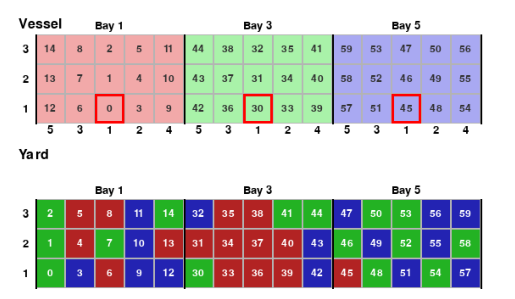

In [3]:
print(env.crane_busy_until,"current time:",env.current_time)
print(env.agent_selection)
# env.step(59)
print(env.agent_selection)
# Get the RGB array
rgb_array = env.render()

# Display the image
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()


In [ ]:
from envs.stowage_aec import StowageAEC
env1 = StowageAEC(config={"num_cranes": 2})
obs1, info = env1.reset()

In [ ]:
env1.obs_coords * env1.num_slot_attrs + env1.num_cranes * 2 + 1

In [ ]:
env1._agent_observation_spaces['crane_0']

In [ ]:
env1.observation_spaces['crane_0']

In [ ]:
env1.observation_space

In [ ]:
env1._agent_observation_spaces

In [ ]:
env1._agent_observation_spaces.keys()

In [ ]:
env1.agents

In [ ]:
env1.observation_space

In [ ]:
config = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 50,
    "group_num": 3,
    "num_cranes": 5, 
    "group_placement": "random",
    "seed": 4307,
    "time_penalty_coef": 0.002
}

env = StowagePZ(config=config)

In [ ]:
import glob
import os
import time

import gymnasium as gym
from sb3_contrib import MaskablePPO
from algorithms.DQN import MaskableDQN
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib.common.wrappers import ActionMasker

import pettingzoo.utils
from pettingzoo.classic import connect_four_v3


# To pass into other gymnasium wrappers, we need to ensure that pettingzoo's wrappper
# can also be a gymnasium Env. Thus, we subclass under gym.Env as well.
class SB3ActionMaskWrapper(pettingzoo.utils.BaseWrapper, gym.Env):
    """Wrapper to allow PettingZoo environments to be used with SB3 illegal action masking."""

    def reset(self, seed=None, options=None):
        """Gymnasium-like reset function which assigns obs/action spaces to be the same for each agent.

        This is required as SB3 is designed for single-agent RL and doesn't expect obs/action spaces to be functions
        """
        super().reset(seed, options)

        # Strip the action mask out from the observation space
        self.observation_space = super().observation_space(self.possible_agents[0])[
            "observation"
        ]
        self.action_space = super().action_space(self.possible_agents[0])

        # Return initial observation, info (PettingZoo AEC envs do not by default)
        return self.observe(self.agent_selection), {}

    def step(self, action):
        """Gymnasium-like step function, returning observation, reward, termination, truncation, info.

        The observation is for the next agent (used to determine the next action), while the remaining
        items are for the agent that just acted (used to understand what just happened).
        """
        current_agent = self.agent_selection

        super().step(action)

        next_agent = self.agent_selection
        return (
            self.observe(next_agent),
            self._cumulative_rewards[current_agent],
            self.terminations[current_agent],
            self.truncations[current_agent],
            self.infos[current_agent],
        )

    def observe(self, agent):
        """Return only raw observation, removing action mask."""
        return super().observe(agent)["observation"]

    def action_mask(self):
        """Separate function used in order to access the action mask."""
        return super().observe(self.agent_selection)["action_mask"]


def mask_fn(env):
    # Do whatever you'd like in this function to return the action mask
    # for the current env. In this example, we assume the env has a
    # helpful method we can rely on.
    return env.action_mask()


def train_action_mask(env_fn, steps=10_000, seed=0, **env_kwargs):
    """Train a single model to play as each agent in a zero-sum game environment using invalid action masking."""
    env = env_fn.env(**env_kwargs)

    print(f"Starting training on {str(env.metadata['name'])}.")

    # Custom wrapper to convert PettingZoo envs to work with SB3 action masking
    env = SB3ActionMaskWrapper(env)

    env.reset(seed=seed)  # Must call reset() in order to re-define the spaces

    env = ActionMasker(env, mask_fn)  # Wrap to enable masking (SB3 function)
    # MaskablePPO behaves the same as SB3's PPO unless the env is wrapped
    # with ActionMasker. If the wrapper is detected, the masks are automatically
    # retrieved and used when learning. Note that MaskablePPO does not accept
    # a new action_mask_fn kwarg, as it did in an earlier draft.
    model = MaskableDQN("MlpPolicy", env, verbose=1, seed=seed)
    model.set_random_seed(seed)
    model.learn(total_timesteps=steps)

    print(f"Finished training on {str(env.unwrapped.metadata['name'])}.\n")

    env.close()


def eval_action_mask(env_fn, num_games=100, render_mode=None, **env_kwargs):
    # Evaluate a trained agent vs a random agent
    env = env_fn.env(render_mode=render_mode, **env_kwargs)

    print(
        f"Starting evaluation vs a random agent. Trained agent will play as {env.possible_agents[1]}."
    )

    try:
        latest_policy = max(
            glob.glob(f"{env.metadata['name']}*.zip"), key=os.path.getctime
        )
    except ValueError:
        print("Policy not found.")
        exit(0)

    model = MaskablePPO.load(latest_policy)

    scores = {agent: 0 for agent in env.possible_agents}
    total_rewards = {agent: 0 for agent in env.possible_agents}
    round_rewards = []

    for i in range(num_games):
        env.reset(seed=i)
        env.action_space(env.possible_agents[0]).seed(i)

        for agent in env.agent_iter():
            obs, reward, termination, truncation, info = env.last()

            # Separate observation and action mask
            observation, action_mask = obs.values()

            if termination or truncation:
                # If there is a winner, keep track, otherwise don't change the scores (tie)
                if (
                    env.rewards[env.possible_agents[0]]
                    != env.rewards[env.possible_agents[1]]
                ):
                    winner = max(env.rewards, key=env.rewards.get)
                    scores[winner] += env.rewards[
                        winner
                    ]  # only tracks the largest reward (winner of game)
                # Also track negative and positive rewards (penalizes illegal moves)
                for a in env.possible_agents:
                    total_rewards[a] += env.rewards[a]
                # List of rewards by round, for reference
                round_rewards.append(env.rewards)
                break
            else:
                if agent == env.possible_agents[0]:
                    act = env.action_space(agent).sample(action_mask)
                else:
                    # Note: PettingZoo expects integer actions # TODO: change chess to cast actions to type int?
                    act = int(
                        model.predict(
                            observation, action_masks=action_mask, deterministic=True
                        )[0]
                    )
            env.step(act)
    env.close()

    # Avoid dividing by zero
    if sum(scores.values()) == 0:
        winrate = 0
    else:
        winrate = scores[env.possible_agents[1]] / sum(scores.values())
    print("Rewards by round: ", round_rewards)
    print("Total rewards (incl. negative rewards): ", total_rewards)
    print("Winrate: ", winrate)
    print("Final scores: ", scores)
    return round_rewards, total_rewards, winrate, scores


if __name__ == "__main__":
    env_fn = connect_four_v3

    env_kwargs = {}

    # Evaluation/training hyperparameter notes:
    # 10k steps: Winrate:  0.76, loss order of 1e-03
    # 20k steps: Winrate:  0.86, loss order of 1e-04
    # 40k steps: Winrate:  0.86, loss order of 7e-06

    # Train a model against itself (takes ~20 seconds on a laptop CPU)
    train_action_mask(env_fn, steps=10_000, seed=0, **env_kwargs)

    # Evaluate 100 games against a random agent (winrate should be ~80%)
    # eval_action_mask(env_fn, num_games=100, render_mode=None, **env_kwargs)